# Block 2 — Readout Orientation and Cell Mapping

The AMS-02 ECAL does not measure a complete transverse $(x,y)$ position in every layer.

Each superlayer contains fibers parallel to one transverse axis and therefore measures position along the perpendicular axis:

$$
x\text{-directed fibers}\rightarrow y\text{ measurement},
\qquad
y\text{-directed fibers}\rightarrow x\text{ measurement}.
$$

This notebook validates:

1. the alternating fiber and measured-axis patterns;
2. continuous-coordinate discretization into 72 cells;
3. vertical and inclined track projection;
4. tracks leaving the active transverse grid.

Energy deposition and the future $18\times21$ crop are outside Block 2.

In [1]:
from math import radians
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ams_ecal import (
    TrackState,
    coordinate_to_cell_index,
    load_geometry,
    measured_axis_for_fiber,
    project_track_to_cell_indices,
    project_track_to_z,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "geometry.yaml"
geometry = load_geometry(CONFIG_PATH)

geometry

ECALGeometry(width_x_mm=648.0, width_y_mm=648.0, depth_z_mm=166.5, number_of_superlayers=9, number_of_layers=18, cells_per_layer=72, cell_pitch_mm=9.0, superlayer_fiber_axes=('x', 'y', 'x', 'y', 'x', 'y', 'x', 'y', 'x'), total_depth_x0=17.0, total_depth_lambda_i=0.6, origin='front_face_center', positive_z_direction='into_ecal', theta_reference_axis='positive_z')

## 1. Fiber direction and measured coordinate

The fiber axis and measured axis must not be confused.

A fiber provides longitudinal continuity along its own direction. Position is determined by identifying which parallel fiber bundle was activated, so the measured coordinate is perpendicular to the fibers.

Each superlayer contributes two readout layers with the same fiber orientation.

In [2]:
measured_axes = tuple(
    measured_axis_for_fiber(fiber_axis)
    for fiber_axis in geometry.layer_fiber_axes
)

print("Layer | z center (mm) | Fiber axis | Measured axis")
print("-" * 54)

for layer_index, (z_mm, fiber_axis, measured_axis) in enumerate(
    zip(
        geometry.uniform_layer_centers_z_mm,
        geometry.layer_fiber_axes,
        measured_axes,
        strict=True,
    )
):
    print(
        f"{layer_index:>5} | "
        f"{z_mm:>13.3f} | "
        f"{fiber_axis:^10} | "
        f"{measured_axis:^13}"
    )

expected_measured_axes = (
    "y", "y", "x", "x",
    "y", "y", "x", "x",
    "y", "y", "x", "x",
    "y", "y", "x", "x",
    "y", "y",
)

assert measured_axes == expected_measured_axes
assert len(measured_axes) == geometry.number_of_layers

Layer | z center (mm) | Fiber axis | Measured axis
------------------------------------------------------
    0 |         4.625 |     x      |       y      
    1 |        13.875 |     x      |       y      
    2 |        23.125 |     y      |       x      
    3 |        32.375 |     y      |       x      
    4 |        41.625 |     x      |       y      
    5 |        50.875 |     x      |       y      
    6 |        60.125 |     y      |       x      
    7 |        69.375 |     y      |       x      
    8 |        78.625 |     x      |       y      
    9 |        87.875 |     x      |       y      
   10 |        97.125 |     y      |       x      
   11 |       106.375 |     y      |       x      
   12 |       115.625 |     x      |       y      
   13 |       124.875 |     x      |       y      
   14 |       134.125 |     y      |       x      
   15 |       143.375 |     y      |       x      
   16 |       152.625 |     x      |       y      
   17 |       161.875 |    

## 2. Continuous coordinate to discrete cell

For a coordinate $u$ along the axis measured by a layer,

$$
i(u)=
\left\lfloor
\frac{u-u_{\min}}{p}
\right\rfloor,
$$

where

$$
u_{\min}=-324\ \mathrm{mm},
\qquad
p=9\ \mathrm{mm}.
$$

The active grid is half-open:

$$
[-324,324).
$$

Therefore, $-324$ mm belongs to cell 0, while $324$ mm is outside the detector.

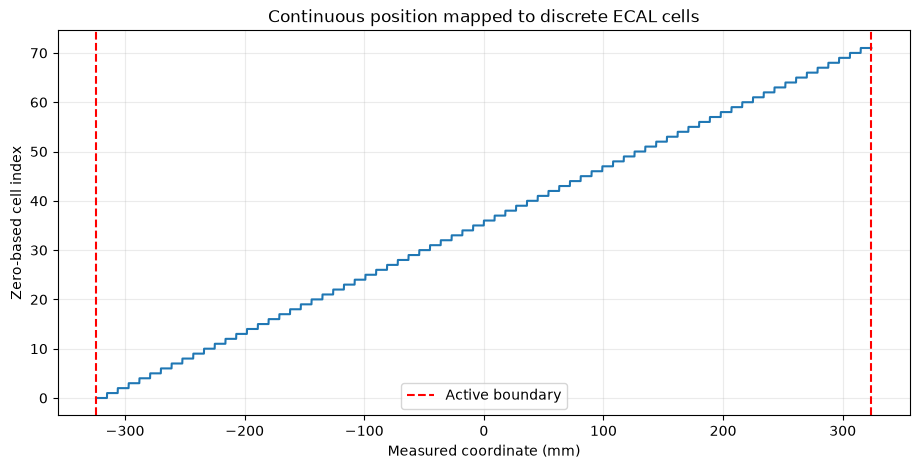

In [3]:
coordinates_mm = np.linspace(-340.0, 340.0, 5000)

cell_indices = np.array(
    [
        (
            np.nan
            if (index := coordinate_to_cell_index(value, geometry)) is None
            else index
        )
        for value in coordinates_mm
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(coordinates_mm, cell_indices, linewidth=1.5)
ax.axvline(-324.0, color="red", linestyle="--", label="Active boundary")
ax.axvline(324.0, color="red", linestyle="--")

ax.set(
    title="Continuous position mapped to discrete ECAL cells",
    xlabel="Measured coordinate (mm)",
    ylabel="Zero-based cell index",
)
ax.grid(alpha=0.25)
ax.legend()

plt.show()

In [4]:
boundary_cases = {
    -324.0: 0,
    -315.0: 1,
    -0.001: 35,
    0.0: 36,
    8.999: 36,
    9.0: 37,
    323.999: 71,
    324.0: None,
}

for coordinate_mm, expected_index in boundary_cases.items():
    actual_index = coordinate_to_cell_index(coordinate_mm, geometry)

    print(
        f"{coordinate_mm:>8.3f} mm -> "
        f"{actual_index!s:>4}"
    )

    assert actual_index == expected_index

-324.000 mm ->    0
-315.000 mm ->    1
  -0.001 mm ->   35
   0.000 mm ->   36
   8.999 mm ->   36
   9.000 mm ->   37
 323.999 mm ->   71
 324.000 mm -> None


## 3. A vertical track

A vertical track has constant $x$ and $y$ throughout the calorimeter. Its reported cell can nevertheless alternate because different superlayers measure different coordinates.

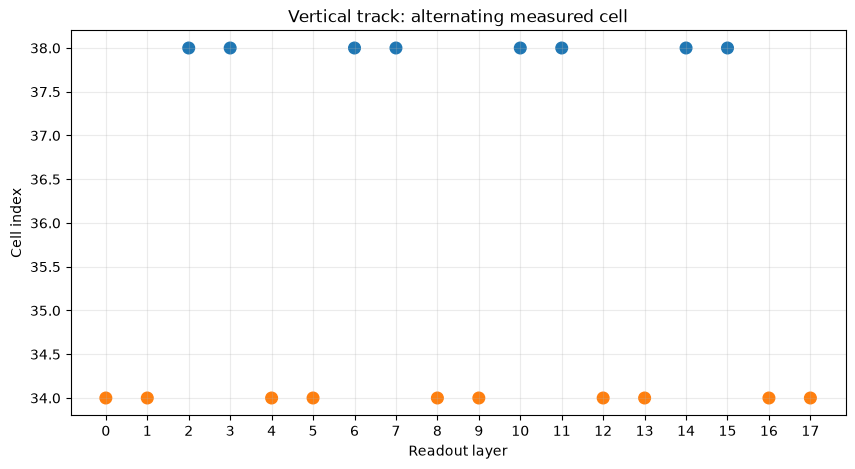

In [5]:
vertical_track = TrackState(
    x0_mm=22.4,
    y0_mm=-17.2,
    z0_mm=0.0,
    theta_rad=0.0,
    phi_rad=0.0,
)

vertical_cells = project_track_to_cell_indices(
    vertical_track,
    geometry,
)

expected_vertical_cells = (
    34, 34, 38, 38,
    34, 34, 38, 38,
    34, 34, 38, 38,
    34, 34, 38, 38,
    34, 34,
)

assert vertical_cells == expected_vertical_cells

layer_indices = np.arange(geometry.number_of_layers)
colors = [
    "tab:blue" if axis == "x" else "tab:orange"
    for axis in measured_axes
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    layer_indices,
    vertical_cells,
    c=colors,
    s=70,
)

ax.set(
    title="Vertical track: alternating measured cell",
    xlabel="Readout layer",
    ylabel="Cell index",
    xticks=layer_indices,
)
ax.grid(alpha=0.25)

plt.show()

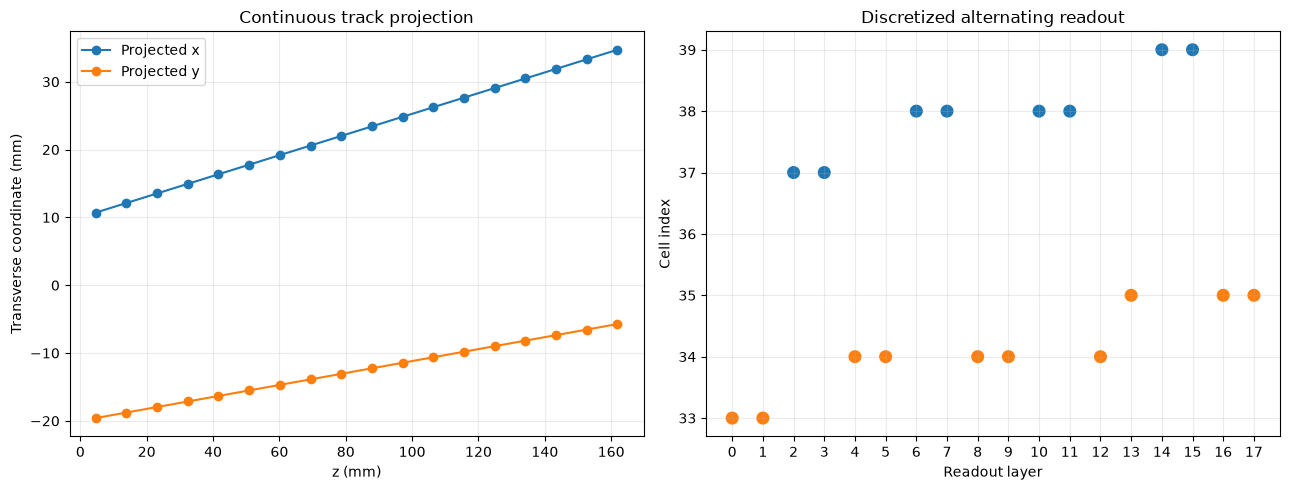

(33, 33, 37, 37, 34, 34, 38, 38, 34, 34, 38, 38, 34, 35, 39, 39, 35, 35)

In [6]:
inclined_track = TrackState(
    x0_mm=10.0,
    y0_mm=-20.0,
    z0_mm=0.0,
    theta_rad=radians(10.0),
    phi_rad=radians(30.0),
)

projections = np.array(
    [
        project_track_to_z(inclined_track, target_z_mm=z_mm)
        for z_mm in geometry.uniform_layer_centers_z_mm
    ]
)

inclined_cells = project_track_to_cell_indices(
    inclined_track,
    geometry,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    projections[:, 2],
    projections[:, 0],
    marker="o",
    label="Projected x",
)
axes[0].plot(
    projections[:, 2],
    projections[:, 1],
    marker="o",
    label="Projected y",
)
axes[0].set(
    title="Continuous track projection",
    xlabel="z (mm)",
    ylabel="Transverse coordinate (mm)",
)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(
    layer_indices,
    inclined_cells,
    c=colors,
    s=70,
)
axes[1].set(
    title="Discretized alternating readout",
    xlabel="Readout layer",
    ylabel="Cell index",
    xticks=layer_indices,
)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

inclined_cells

In [7]:
edge_track = TrackState(
    x0_mm=320.0,
    y0_mm=0.0,
    z0_mm=0.0,
    theta_rad=radians(10.0),
    phi_rad=0.0,
)

edge_cells = project_track_to_cell_indices(
    edge_track,
    geometry,
)

for layer_index, (measured_axis, cell_index) in enumerate(
    zip(measured_axes, edge_cells, strict=True)
):
    print(
        f"Layer {layer_index:>2}: "
        f"measures {measured_axis}, "
        f"cell = {cell_index}"
    )

assert any(cell_index is None for cell_index in edge_cells)
assert len(edge_cells) == geometry.number_of_layers

Layer  0: measures y, cell = 36
Layer  1: measures y, cell = 36
Layer  2: measures x, cell = None
Layer  3: measures x, cell = None
Layer  4: measures y, cell = 36
Layer  5: measures y, cell = 36
Layer  6: measures x, cell = None
Layer  7: measures x, cell = None
Layer  8: measures y, cell = 36
Layer  9: measures y, cell = 36
Layer 10: measures x, cell = None
Layer 11: measures x, cell = None
Layer 12: measures y, cell = 36
Layer 13: measures y, cell = 36
Layer 14: measures x, cell = None
Layer 15: measures x, cell = None
Layer 16: measures y, cell = 36
Layer 17: measures y, cell = 36


## Conclusions

Block 2 establishes the following detector representation:

$$
(\text{track},\text{layer})
\rightarrow
(x_\ell,y_\ell)
\rightarrow
\text{layer-specific measured coordinate}
\rightarrow
c_\ell\in\{0,\ldots,71\}\cup\{\mathrm{None}\}.
$$

The resulting track-cell sequence has 18 entries, but each layer supplies only one transverse coordinate.

Successive perpendicular views allow the calorimeter shower to be interpreted spatially without incorrectly representing each layer as a $72\times72$ pixel plane.

The $18\times21$ track-centred crop will be introduced later, after the canonical event representation and energy-deposition model exist.